In [1]:
# Import all the necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
# Sets the number of examples.
M = 100

# Reset pseudo random number generator so that the results are reproducible.
np.random.seed(42)

# Create target function and its noisy version.
x = np.random.uniform(-3, 3, (M, 1))
n = np.random.normal(0, 1, (M,1))
y = 2 + x + 0.5*x**2
y_noisy = y + n
            
# Mtest = 100
# x_test = np.linspace(-10, 10, Mtest).reshape(Mtest, 1)
# y_test = 2 + x_test + 0.5*x_test**2 + n

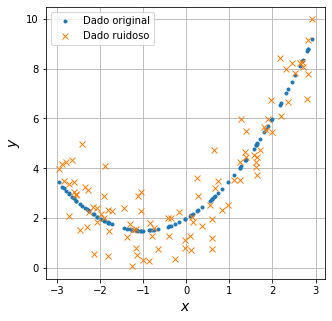

In [3]:
# Plote dos dados originais vs versão ruidosa.
fig = plt.figure(figsize=(5,5))
plt.plot(x, y, '.', label='Dado original')
plt.plot(x, y_noisy, 'x', label='Dado ruidoso')
# plt.plot(x_test, y_test, 'o', label='Dado teste')
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.legend()
plt.grid()
#plt.savefig("target_function.png", dpi=600)
#Show the plot.
plt.show()

In [4]:
# Ordem do polinómio.
model_order = 90

In [5]:
# Fator de Regularização.
lambdas = np.linspace(10**-10, 1, 1000)

2f) o valor ótimo para lambda é: 1.0


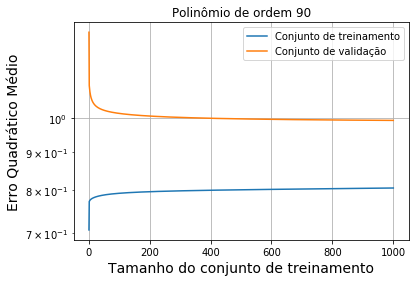

In [6]:
# exercício 2b-2c-2d-2f

# Split the whole set into random training and validation set.
x_train, x_val, y_train, y_val = train_test_split(x, y_noisy, test_size=0.3, random_state=10)

include_bias = False

N = 1000

a_hist = np.zeros((model_order, N)) if include_bias == False else np.zeros((model_order+1, N))

# vetor do erro de treinamento
error_training = []

# vetor do erro de validação/predição
error_validation = []

minimum_val_error = float("inf")

for i in range(0,len(lambdas)):
    # Instantiate a polynomial with the given degree.
    poly_features = PolynomialFeatures(degree=model_order, include_bias=include_bias)
    # Instantiate a scaler that will standardize the features.
    std_scaler = StandardScaler()
    # Instantiate a Ridge regressor.
    reg = Ridge(alpha=lambdas[i])
    # Create a pipeline of actions.
    model = Pipeline([
        ("poly_features", poly_features),
        ("std_scaler", std_scaler),
        ("reg", reg),
    ])
    # Train model.        
    model.fit(x_train, y_train)
       
    # Use the trained model for prediction of the training set.
    y_train_predict = model.predict(x_train)

    # Use the trained model for prediction of the validation set.
    y_val_predict = model.predict(x_val)       

    # Calculate MSE for training set.
    error_training.append(mean_squared_error(y_train, y_train_predict))
 
    # Calculate MSE for validation set.
    error_validation_aux = mean_squared_error(y_val, y_val_predict)
    error_validation.append(error_validation_aux)
    
    if error_validation_aux < minimum_val_error:
        l = lambdas[i]
        mdl = model
        a = mdl.named_steps['reg'].coef_
        a_hist[:,i] = a
        minimum_val_error = error_validation_aux
        
    
plt.plot(range(1,len(lambdas)+1), np.sqrt(error_training), label='Conjunto de treinamento')
plt.plot(range(1,len(lambdas)+1), np.sqrt(error_validation), label='Conjunto de validação')
plt.yscale('log')
plt.xlabel('Tamanho do conjunto de treinamento', fontsize=14)
plt.ylabel('Erro Quadrático Médio', fontsize=14)
plt.grid()
plt.title('Polinômio de ordem '+str(model_order))
plt.legend(loc='best')
print('2f) o valor ótimo para lambda é: '+str(l))

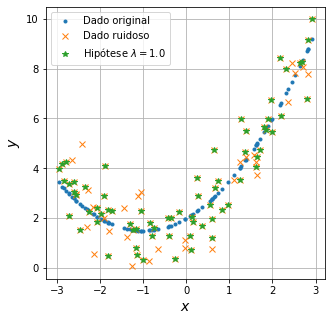

In [7]:
# exercício 2g
# Plote dos dados originais vs versão ruidosa vs modelo treinado.
fig = plt.figure(figsize=(5,5))
plt.plot(x, y, '.', label='Dado original')
plt.plot(x, y_noisy, 'x', label='Dado ruidoso')
plt.plot(x_train, y_train, '*', label='Hipótese $\lambda=$'+str(l))    
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.legend()
plt.grid()
#Show the plot.
plt.show()

In [8]:
# exercício 2h
print('Valores dos pesos obtidos durante o treinamento do modelo com menor erro de validação:')
print(a)

Valores dos pesos obtidos durante o treinamento do modelo com menor erro de validação:
[[ 1.55288255e+00  1.41595431e+00  2.37421122e-01  4.66050959e-01
   1.21513589e-01  4.30098819e-02  9.33210077e-02 -1.31307230e-01
   3.03739145e-02 -1.86317248e-01 -3.75534691e-02 -1.84614431e-01
  -8.84730765e-02 -1.57663355e-01 -1.17319088e-01 -1.21647367e-01
  -1.27124376e-01 -8.47340840e-02 -1.23151499e-01 -5.07925273e-02
  -1.10381019e-01 -2.14121881e-02 -9.27418635e-02  2.99111990e-03
  -7.30578655e-02  2.25777539e-02 -5.32301564e-02  3.77677826e-02
  -3.44607908e-02  4.90772801e-02 -1.74501263e-02  5.70362551e-02
  -2.55178880e-03  6.21495167e-02  1.01124531e-02  6.48797362e-02
   2.05703521e-02  6.56417274e-02  2.89415250e-02  6.48022150e-02
   3.53978483e-02  6.26821484e-02  4.01367740e-02  5.95600829e-02
   4.33637515e-02  5.56759114e-02  4.52809873e-02  5.12346067e-02
   4.60805679e-02  4.64098287e-02  4.59405450e-02  4.13473316e-02
   4.50230048e-02  3.61681504e-02  4.34734398e-02  3.09

**2j) O que você percebe com relação aos pesos obtidos com as regressões Ridge e LASSO?**
- R: os valores dos pesos para a regressão Ridge tende a um valor constante próximo de -2,53, não chega a produzir pesos iguais a zero.